# Packages

In [2]:
# core
import pandas as pd
import numpy as np
import polars as pl
import math
import requests

# scipy / stats
import scipy.stats as stats
from scipy.optimize import minimize

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tsa.deterministic import DeterministicProcess, CalendarFourier
from statsmodels.graphics.tsaplots import plot_pacf

# sklearn
from sklearn.model_selection import (
    GroupKFold, KFold, train_test_split, cross_val_score, TimeSeriesSplit
)
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.metrics import (
    mean_squared_error, r2_score, make_scorer, accuracy_score,
    median_absolute_error, classification_report, mean_absolute_error,
    roc_auc_score, roc_curve
)
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    StackingRegressor, RandomForestClassifier
)

# bambi
import bambi as bmb
import arviz as az

# gradient boosting
import xgboost as xgb
import lightgbm as lgb

# optimization
import optuna

# pandas display settings
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.float_format', lambda x: "%.4f" % x)
pd.options.plotting.backend = "plotly"

# plotting styles
plt.style.use('ggplot')
sns.set_style('darkgrid')


# Data

In [3]:
data = pd.read_csv("data/final_dataset.csv")
data.head()

,ori,subject_race,month,agency_name,state,geoid_county,geoid_place,geo_type,place_name,total_pop,median_hh_income,housing_units,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic,total_arrests,force_baton,force_canine,force_chem_spray,force_gun,force_less_lethal_weapon,force_neck_hold,force_pressure_point,force_restraint,force_strike,force_takedown,force_taser,force_unknown,force_total
0,CA0010100,asian,1,alameda police,CA,6001,600562,place,"Alameda city, California",76876.0000,132015.0000,32129.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420,2,0,0,0,0,0,0,0,0,2,0,0,0,2
1,CA0010100,asian,2,alameda police,CA,6001,600562,place,"Alameda city, California",76876.0000,132015.0000,32129.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420,4,0,0,0,0,0,0,0,0,0,0,0,0,0
2,CA0010100,asian,3,alameda police,CA,6001,600562,place,"Alameda city, California",76876.0000,132015.0000,32129.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420,8,0,0,0,0,0,0,0,0,0,0,0,0,0
3,CA0010100,asian,4,alameda police,CA,6001,600562,place,"Alameda city, California",76876.0000,132015.0000,32129.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420,4,0,0,0,0,0,0,0,0,0,0,0,0,0
4,CA0010100,asian,5,alameda police,CA,6001,600562,place,"Alameda city, California",76876.0000,132015.0000,32129.0000,33357.0000,4659.0000,367.0000,23254.0000,347.0000,3719.0000,11173.0000,10915.0000,place,0.4339,0.0606,0.0048,0.3025,0.0045,0.0484,0.1453,0.1420,2,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
data.shape

(66192, 43)

In [5]:
ca_pivot = (
    data
        .query("ori == 'CA0010100'")
        .pivot_table(
            index="month",
            columns="subject_race",
            values=["total_arrests", "force_total"],
            aggfunc="sum"
        )
)
ca_pivot.columns = [f"{metric}_{race}" for metric, race in ca_pivot.columns]
ca_pivot.plot(title="CA0010100 — Arrests & Force by Race Over Time").show()

In [6]:
data["subject_race"].value_counts()

subject_race
asian               9456
black               9456
hispanic            9456
native american     9456
pacific islander    9456
unknown             9456
white               9456
Name: count, dtype: int64

In [7]:
data["subject_race"] = pd.Categorical(
    data["subject_race"],
    categories=["white", "black", "hispanic", "asian", "native american", "pacific islander", "unknown"]
)

# Looking at NJ

In [8]:
nj_data = data[lambda x: (x.state == "NJ") & (x.subject_race != "unknown")]
nj_data

,ori,subject_race,month,agency_name,state,geoid_county,geoid_place,geo_type,place_name,total_pop,median_hh_income,housing_units,race_white,race_black,race_aian,race_asian,race_nhopi,race_other,race_two_or_more,hispanic,geo_source,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_other,pct_two_or_more,pct_hispanic,total_arrests,force_baton,force_canine,force_chem_spray,force_gun,force_less_lethal_weapon,force_neck_hold,force_pressure_point,force_restraint,force_strike,force_takedown,force_taser,force_unknown,force_total
23688,NJ0010100,asian,1,absecon police,NJ,34001,3400100,place,"Absecon city, New Jersey",9099.0000,77516.0000,3759.0000,6194.0000,974.0000,87.0000,509.0000,68.0000,232.0000,1035.0000,1380.0000,place,0.6807,0.1070,0.0096,0.0559,0.0075,0.0255,0.1137,0.1517,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23689,NJ0010100,asian,2,absecon police,NJ,34001,3400100,place,"Absecon city, New Jersey",9099.0000,77516.0000,3759.0000,6194.0000,974.0000,87.0000,509.0000,68.0000,232.0000,1035.0000,1380.0000,place,0.6807,0.1070,0.0096,0.0559,0.0075,0.0255,0.1137,0.1517,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23690,NJ0010100,asian,3,absecon police,NJ,34001,3400100,place,"Absecon city, New Jersey",9099.0000,77516.0000,3759.0000,6194.0000,974.0000,87.0000,509.0000,68.0000,232.0000,1035.0000,1380.0000,place,0.6807,0.1070,0.0096,0.0559,0.0075,0.0255,0.1137,0.1517,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23691,NJ0010100,asian,4,absecon police,NJ,34001,3400100,place,"Absecon city, New Jersey",9099.0000,77516.0000,3759.0000,6194.0000,974.0000,87.0000,509.0000,68.0000,232.0000,1035.0000,1380.0000,place,0.6807,0.1070,0.0096,0.0559,0.0075,0.0255,0.1137,0.1517,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23692,NJ0010100,asian,5,absecon police,NJ,34001,3400100,place,"Absecon city, New Jersey",9099.0000,77516.0000,3759.0000,6194.0000,974.0000,87.0000,509.0000,68.0000,232.0000,1035.0000,1380.0000,place,0.6807,0.1070,0.0096,0.0559,0.0075,0.0255,0.1137,0.1517,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47287,NJNPD0000,white,8,newark police,NJ,34013,3451000,place,"Newark city, New Jersey",307188.0000,48416.0000,121604.0000,50749.0000,143359.0000,2353.0000,5731.0000,124.0000,62623.0000,42249.0000,114280.0000,place,0.1652,0.4667,0.0077,0.0187,0.0004,0.2039,0.1375,0.3720,21,0,0,0,0,0,0,0,0,0,0,0,0,0
47288,NJNPD0000,white,9,newark police,NJ,34013,3451000,place,"Newark city, New Jersey",307188.0000,48416.0000,121604.0000,50749.0000,143359.0000,2353.0000,5731.0000,124.0000,62623.0000,42249.0000,114280.0000,place,0.1652,0.4667,0.0077,0.0187,0.0004,0.2039,0.1375,0.3720,27,0,0,0,0,0,0,0,0,1,0,0,0,1
47289,NJNPD0000,white,10,newark police,NJ,34013,3451000,place,"Newark city, New Jersey",307188.0000,48416.0000,121604.0000,50749.0000,143359.0000,2353.0000,5731.0000,124.0000,62623.0000,42249.0000,114280.0000,place,0.1652,0.4667,0.0077,0.0187,0.0004,0.2039,0.1375,0.3720,27,0,0,0,0,0,0,0,0,1,2,0,0,3
47290,NJNPD0000,white,11,newark police,NJ,34013,3451000,place,"Newark city, New Jersey",307188.0000,48416.0000,121604.0000,50749.0000,143359.0000,2353.0000,5731.0000,124.0000,62623.0000,42249.0000,114280.0000,place,0.1652,0.4667,0.0077,0.0187,0.0004,0.2039,0.1375,0.3720,24,0,0,0,0,0,0,0,0,0,1,0,0,1


In [9]:
nj_data["subject_race"].unique()

['asian', 'black', 'hispanic', 'native american', 'pacific islander', 'white']
Categories (7, str): ['white', 'black', 'hispanic', 'asian', 'native american', 'pacific islander', 'unknown']

In [10]:
nj_data["ori"].nunique() * nj_data["subject_race"].nunique() * 12

20232

In [11]:
nj_data["ori"].nunique() * nj_data["subject_race"].nunique()

1686

In [74]:
census_vars = ["total_pop", "median_hh_income", "housing_units",
               "pct_white", "pct_black", "pct_aian", "pct_asian", "pct_nhopi", "pct_hispanic"]

nj_data_annual = (
    nj_data
        .groupby(["ori", "subject_race", "agency_name", "state"] + census_vars, observed=True)
        .agg(
            total_arrests=("total_arrests", "sum"),
            force_total=("force_total", "sum"),
            months_reporting=("total_arrests", lambda x: (x > 0).sum()),  # how many months had arrests
        )
        .reset_index()
        .assign(force_arrest_ratio = lambda x: x.force_total / (x.total_arrests + 1))
)
nj_data_annual

,ori,subject_race,agency_name,state,total_pop,median_hh_income,housing_units,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_hispanic,total_arrests,force_total,months_reporting,force_arrest_ratio
0,NJ0010100,white,absecon police,NJ,9099.0000,77516.0000,3759.0000,0.6807,0.1070,0.0096,0.0559,0.0075,0.1517,81,16,12,0.1951
1,NJ0010100,black,absecon police,NJ,9099.0000,77516.0000,3759.0000,0.6807,0.1070,0.0096,0.0559,0.0075,0.1517,63,13,12,0.2031
2,NJ0010100,hispanic,absecon police,NJ,9099.0000,77516.0000,3759.0000,0.6807,0.1070,0.0096,0.0559,0.0075,0.1517,28,0,10,0.0000
3,NJ0010100,asian,absecon police,NJ,9099.0000,77516.0000,3759.0000,0.6807,0.1070,0.0096,0.0559,0.0075,0.1517,0,1,0,1.0000
4,NJ0010100,native american,absecon police,NJ,9099.0000,77516.0000,3759.0000,0.6807,0.1070,0.0096,0.0559,0.0075,0.1517,1,0,1,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,NJNPD0000,black,newark police,NJ,307188.0000,48416.0000,121604.0000,0.1652,0.4667,0.0077,0.0187,0.0004,0.3720,4417,869,12,0.1967
1682,NJNPD0000,hispanic,newark police,NJ,307188.0000,48416.0000,121604.0000,0.1652,0.4667,0.0077,0.0187,0.0004,0.3720,1698,273,12,0.1607
1683,NJNPD0000,asian,newark police,NJ,307188.0000,48416.0000,121604.0000,0.1652,0.4667,0.0077,0.0187,0.0004,0.3720,25,2,10,0.0769
1684,NJNPD0000,native american,newark police,NJ,307188.0000,48416.0000,121604.0000,0.1652,0.4667,0.0077,0.0187,0.0004,0.3720,6,0,3,0.0000


In [75]:
nj_data_annual.sort_values(by="force_arrest_ratio")

,ori,subject_race,agency_name,state,total_pop,median_hh_income,housing_units,pct_white,pct_black,pct_aian,pct_asian,pct_nhopi,pct_hispanic,total_arrests,force_total,months_reporting,force_arrest_ratio
842,NJ0081800,hispanic,"washington township, gloucester county police",NJ,48961.0000,114520.0000,18822.0000,0.8214,0.0624,0.0023,0.0411,0.0000,0.0540,5,0,2,0.0000
991,NJ0121200,black,milltown police,NJ,6994.0000,119958.0000,2632.0000,0.7845,0.0458,0.0000,0.0343,0.0000,0.1051,19,0,9,0.0000
989,NJ0121100,pacific islander,middlesex police,NJ,14518.0000,107063.0000,5703.0000,0.6071,0.0712,0.0156,0.1165,0.0000,0.2632,0,0,0,0.0000
988,NJ0121100,native american,middlesex police,NJ,14518.0000,107063.0000,5703.0000,0.6071,0.0712,0.0156,0.1165,0.0000,0.2632,0,0,0,0.0000
987,NJ0121100,asian,middlesex police,NJ,14518.0000,107063.0000,5703.0000,0.6071,0.0712,0.0156,0.1165,0.0000,0.2632,0,0,0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,NJ0033500,black,springfield township police,NJ,3239.0000,143343.0000,1260.0000,0.8833,0.0235,0.0028,0.0139,0.0000,0.0713,4,13,4,2.6000
1532,NJ0190400,hispanic,byram township police,NJ,8082.0000,137367.0000,3297.0000,0.8424,0.0126,0.0000,0.0202,0.0000,0.1349,0,3,0,3.0000
1278,NJ0151000,white,island heights police,NJ,1691.0000,107308.0000,894.0000,0.9367,0.0195,0.0000,0.0018,0.0000,0.0568,1,6,1,3.0000
144,NJ0021600,white,englewood cliffs police,NJ,5330.0000,222192.0000,2029.0000,0.4614,0.0176,0.0000,0.4420,0.0000,0.0779,1,6,1,3.0000


In [76]:
import plotly.graph_objs as go
import plotly.subplots as sp

races = nj_data_annual["subject_race"].unique()
n_races = len(races)

fig = sp.make_subplots(rows=1, cols=n_races, subplot_titles=[race.title() for race in races])

for i, race in enumerate(races):
    values = nj_data_annual.loc[nj_data_annual["subject_race"] == race, "force_arrest_ratio"]
    fig.add_trace(
        go.Histogram(x=values, name=race.title(), showlegend=False),
        row=1, col=i+1
    )

fig.update_layout(
    height=400, width=200 * n_races,
    title_text="Force-to-Arrest Ratio Distribution by Subject Race (NJ)",
    bargap=0.2,
)
fig.update_xaxes(title_text="Force/Arrest Ratio")
fig.update_yaxes(title_text="Count")

fig.show()

In [17]:
census_vars = ["total_pop", "median_hh_income", "housing_units",
               "pct_white", "pct_black", "pct_aian", "pct_asian", "pct_nhopi", "pct_hispanic"]


In [ ]:
# Aggregate to annual level: one row per (ori, subject_race)
# Census vars are constant within agency, so take first value
model_data = (
    nj_data
    .groupby(["ori", "subject_race", "agency_name", "state"] + census_vars, observed=True)
    .agg(
        total_arrests=("total_arrests", "sum"),
        force_total=("force_total", "sum"),
        months_reporting=("total_arrests", lambda x: (x > 0).sum()),
    )
    .reset_index()
)

# Flag agencies that had sparse reporting (fewer than 6 months with arrests)
model_data["sparse_reporting"] = (model_data["months_reporting"] < 6).astype(int)

model_data["log_arrests"] = np.log(model_data["total_arrests"] + 1)

# Standardize continuous covariates
scaler = StandardScaler()
model_data[census_vars] = scaler.fit_transform(model_data[census_vars])

print(f"Rows: {len(model_data):,}  |  Departments: {model_data['ori'].nunique()}  |  Races: {model_data['subject_race'].nunique()}")
print(f"Sparse-reporting rows: {model_data['sparse_reporting'].sum()} ({model_data['sparse_reporting'].mean():.1%})")
print(model_data.groupby("subject_race")[["total_arrests", "force_total"]].sum())

priors = {
    "Intercept": bmb.Prior("Normal", mu=-2.65, sigma=1),
}

model = bmb.Model(
    """force_total ~ C(subject_race, Treatment('white'))
        + total_pop + median_hh_income + housing_units
        + pct_white + pct_black + pct_hispanic
        + offset(log_arrests)
        """,
    model_data,
    family="negativebinomial",
    link="log",
    priors=priors,
)

idata = model.fit(
    draws=1000, tune=1000, target_accept=0.9,
    inference_method="numpyro_nuts",
    idata_kwargs={"log_likelihood": True}
)

In [ ]:
# Raw (unconditional) median force rate per race across NJ agencies
nj_annual = (
    data
    .query("state == 'NJ' and subject_race != 'unknown'")
    .groupby(["ori", "subject_race"], observed=True)
    .agg(total_arrests=("total_arrests", "sum"), force_total=("force_total", "sum"))
    .assign(force_rate=lambda x: x["force_total"] / (x["total_arrests"] + 1))
    .reset_index()
)

(
    nj_annual
    .groupby("subject_race", observed=True)[["force_rate", "total_arrests", "force_total"]]
    .median()
    .sort_values("force_rate", ascending=False)
)

In [ ]:
# Baseline: same controls but no subject_race
baseline_model = bmb.Model(
    """force_total ~ total_pop + median_hh_income + housing_units
        + pct_white + pct_black + pct_hispanic
        + offset(log_arrests)
        """,
    model_data,
    family="negativebinomial",
    link="log",
)
idata_baseline = baseline_model.fit(
    draws=1000, tune=1000, target_accept=0.9,
    inference_method="numpyro_nuts",
    idata_kwargs={"log_likelihood": True}
)

          rank   elpd_loo   p_loo  elpd_diff  weight      se     dse  warning  \
full         0 -2776.1165 13.4355     0.0000  1.0000 76.1258  0.0000    False   
baseline     1 -2880.4318  8.3428   104.3153  0.0000 74.3235 10.4566    False   

         scale  
full       log  
baseline   log  


<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

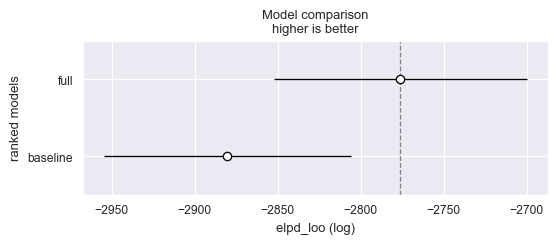

In [ ]:
# LOO-ELPD comparison — higher is better
# A difference of >4 ELPD points is considered meaningful
loo_full = az.loo(idata, pointwise=True)
loo_baseline = az.loo(idata_baseline, pointwise=True)

comparison = az.compare({"full": idata, "baseline": idata_baseline})
print(comparison)
az.plot_compare(comparison)

In [81]:
# inspect actual variable names
print(list(idata.posterior.data_vars))

# R-hat and ESS — should be ~1.0 and >400 respectively
az.summary(idata, var_names=["subject_race"], filter_vars="like")

['Intercept', "C(subject_race, Treatment('white'))", 'total_pop', 'median_hh_income', 'housing_units', 'pct_white', 'pct_black', 'pct_hispanic', 'alpha']


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"C(subject_race, Treatment('white'))[asian]",-0.7230,0.1260,-0.9670,-0.4950,0.0020,0.0020,3640.0000,2790.0000,1.0000
"C(subject_race, Treatment('white'))[black]",0.0230,0.0870,-0.1420,0.1880,0.0010,0.0010,3469.0000,3049.0000,1.0000
"C(subject_race, Treatment('white'))[hispanic]",-0.3290,0.0880,-0.4910,-0.1560,0.0020,0.0010,3169.0000,3144.0000,1.0000
"C(subject_race, Treatment('white'))[native american]",-2.3990,0.3660,-3.0690,-1.6930,0.0050,0.0060,4641.0000,2646.0000,1.0000
"C(subject_race, Treatment('white'))[pacific islander]",-7.0660,2.3980,-11.6730,-3.2870,0.0590,0.0530,2036.0000,1813.0000,1.0000


array([[<Axes: title={'center': "C(subject_race, Treatment('white'))"}>,
        <Axes: title={'center': "C(subject_race, Treatment('white'))"}>]],
      dtype=object)

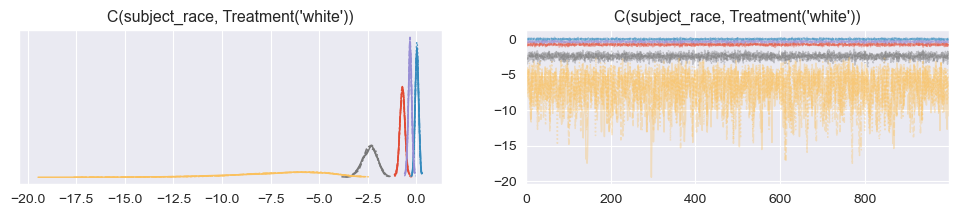

In [82]:
# trace plots — chains should mix well ("fuzzy caterpillars")
az.plot_trace(idata, var_names=["subject_race"], filter_vars="like")

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

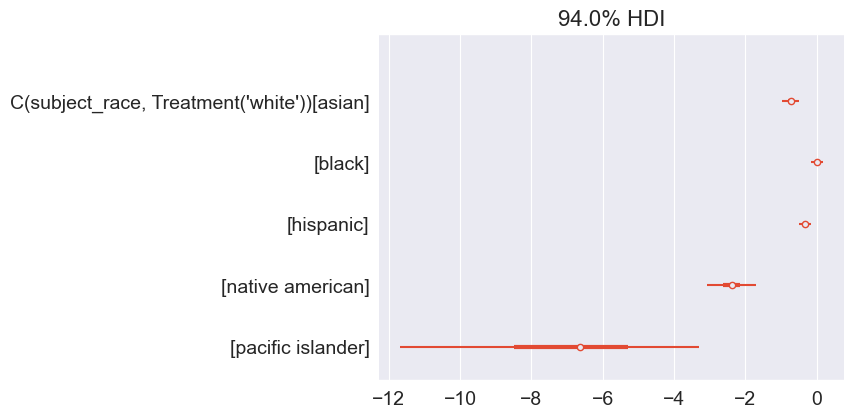

In [83]:
# posterior of race coefficients with credible intervals
az.plot_forest(idata, var_names=["subject_race"], filter_vars="like", combined=True)

/Users/kylewang/miniconda3/envs/uof/lib/python3.11/site-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Axes: xlabel='force_total'>

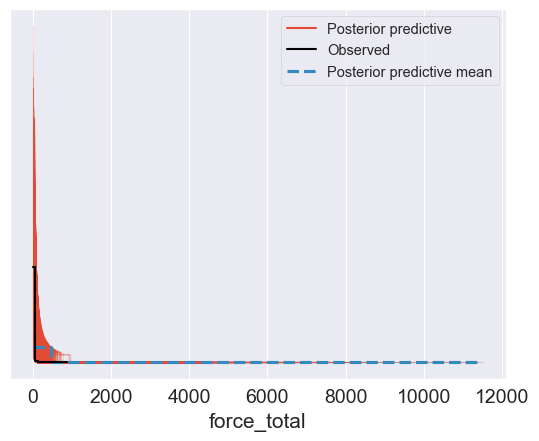

In [84]:
# posterior predictive check — does the model fit the data?
model.predict(idata, kind="pps")
az.plot_ppc(idata)

In [ ]:
# Exponentiate race coefficients to get Incidence Rate Ratios (IRRs)
# Using posterior median (robust to skew in the posterior)
# IRR > 1 means more force relative to white subjects, conditional on arrest and controls
summary = az.summary(idata, var_names=["subject_race"], filter_vars="like", stat_funcs={"median": np.median})
summary["IRR"] = np.exp(summary["median"])
summary["IRR_low"] = np.exp(summary["hdi_3%"])
summary["IRR_high"] = np.exp(summary["hdi_97%"])
print(summary[["median", "sd", "hdi_3%", "hdi_97%", "r_hat", "IRR", "IRR_low", "IRR_high"]])

In [ ]:
# Posterior predicted force counts — median over all posterior draws
model.predict(idata, kind="mean")

predicted_force = idata.posterior["mu"].median(dim=["chain", "draw"]).values

(
    model_data
    .assign(
        predicted_force=predicted_force,
        predicted_rate=predicted_force / (model_data["total_arrests"] + 1)
    )
    .groupby("subject_race", observed=True)[["predicted_rate", "predicted_force"]]
    .median()
    .sort_values("predicted_rate", ascending=False)
)

In [128]:
model.predict(idata, kind="mean")
predicted_force = idata.posterior["mu"].median(dim=["chain", "draw"]).values

plot_df = model_data.assign(predicted=predicted_force)

lim = max(plot_df["force_total"].max(), plot_df["predicted"].max()) * 1.05

fig = px.scatter(
    plot_df,
    x="force_total",
    y="predicted",
    color="subject_race",
    hover_data=["agency_name", "ori", "subject_race", "force_total", "total_arrests"],
    labels={"force_total": "Observed force total", "predicted": "Posterior median predicted force total"},
    title="Predicted vs. Realized — NJ Annual Model",
    opacity=0.7,
)
fig.add_shape(type="line", x0=0, y0=0, x1=lim, y1=lim,
              line=dict(color="black", dash="dash", width=1))
fig.show()

fig.write_image("dist_predicted_force_rate.png", scale=2)

/Users/kylewang/miniconda3/envs/uof/lib/python3.11/site-packages/bambi/models.py:915: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(


ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [132]:
pivot = (
    data
        .query("ori == 'NJNPD0000'")
        .pivot_table(
            index="month",
            columns="subject_race",
            values=["total_arrests", "force_total"],
            aggfunc="sum"
        )
)
pivot.columns = [f"{metric}_{race}" for metric, race in pivot.columns]
pivot.plot(title="NJNPD0000 — Arrests & Force by Race Over Time").show()

In [ ]:
(model_data
    .assign(force_rate = lambda x: x["force_total"] / (x["total_arrests"] + 1))
    .groupby("subject_race")[["force_rate", "total_arrests", "force_total"]]
    .median()
    .sort_values("force_rate", ascending=False)
)

,force_rate,total_arrests,force_total
subject_race,,,
black,0.1364,30.0000,5.0000
white,0.1293,50.0000,7.0000
hispanic,0.0865,26.0000,3.0000
asian,0.0000,2.0000,0.0000
native american,0.0000,0.0000,0.0000
pacific islander,0.0000,0.0000,0.0000


In [ ]:
print(model_data.groupby("ori")["subject_race"].count().describe())


count   281.0000
mean      6.0000
std       0.0000
min       6.0000
25%       6.0000
50%       6.0000
75%       6.0000
max       6.0000
Name: subject_race, dtype: float64


In [133]:

# Total predicted force in NJ — correct method: sum within each draw, then summarize
# idata.posterior["mu"] requires model.predict(idata, kind="mean") to have been called first

# Find the obs dimension name
mu = idata.posterior["mu"]
obs_dim = [d for d in mu.dims if d not in ("chain", "draw")][0]
print(f"Obs dimension: {obs_dim}, shape: {dict(mu.sizes)}")

# Sum over observations within each (chain, draw) — shape becomes (chain, draw)
total_by_draw = mu.sum(dim=obs_dim)

# Summarize
posterior_mean = float(total_by_draw.mean())
posterior_median = float(total_by_draw.median())
hdi = az.hdi(total_by_draw.values.flatten(), hdi_prob=0.94)

print(f"\nTotal predicted force incidents in NJ (model_data period):")
print(f"  Posterior mean:   {posterior_mean:,.0f}")
print(f"  Posterior median: {posterior_median:,.0f}")
print(f"  94% HDI:          [{hdi[0]:,.0f}, {hdi[1]:,.0f}]")
print(f"\nObserved total:     {model_data['force_total'].sum():,.0f}")


Obs dimension: __obs__, shape: {'chain': 4, 'draw': 1000, '__obs__': 1686}

Total predicted force incidents in NJ (model_data period):
  Posterior mean:   15,102
  Posterior median: 15,009
  94% HDI:          [13,243, 17,221]

Observed total:     12,028


## NJ Monthly Model

In [18]:
(
    nj_data
        .groupby(["month"])
        .agg({
            "total_arrests" : "sum",
            "force_total" : "sum"
        })
        .plot()
)

In [19]:
nj_data = (
    nj_data.assign(
        sin_month= lambda x: np.sin(2 * np.pi * x.month / 12),
        cos_month= lambda x: np.cos(2 * np.pi * x.month / 12),
        log_arrests= lambda x: np.log(x.total_arrests + 1)
    )
)

In [20]:
formula = """
    force_total ~ C(subject_race, Treatment('white'))
        + total_pop + median_hh_income + housing_units
        + pct_white + pct_black + pct_hispanic
        + sin_month + cos_month
        + (1|ori)
        + offset(log_arrests)
"""

In [21]:
model_data = nj_data.copy()

In [22]:
# Standardize continuous covariates
scaler = StandardScaler()
model_data[census_vars] = scaler.fit_transform(model_data[census_vars])

print(f"Rows: {len(model_data):,}  |  Departments: {model_data['ori'].nunique()}  |  Races: {model_data['subject_race'].nunique()}")
print(model_data.groupby("subject_race")[["total_arrests", "force_total"]].sum())

priors = {
    "Intercept": bmb.Prior("Normal", mu=-2.65, sigma=1),
}

model = bmb.Model(
    formula,
    model_data,
    family="negativebinomial",
    link="log",
    priors=priors,
)

idata = model.fit(
    draws=1000, tune=1000, target_accept=0.9,
    inference_method="numpyro_nuts",
    idata_kwargs={"log_likelihood": True}
)

Rows: 20,232  |  Departments: 281  |  Races: 6
                  total_arrests  force_total
subject_race                                
white                     23859         3452
black                     27204         5157
hispanic                  21210         3225
asian                      1467          186
native american             127            8
pacific islander             42            0


/Users/kylewang/miniconda3/envs/uof/lib/python3.11/site-packages/bambi/backend/pymc.py:124: FutureWarning: 'numpyro_nuts' has been replaced by 'numpyro' and will be removed in a future release.
  warnings.warn(


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

In [23]:
loo_full = az.loo(idata, pointwise=True)
print(loo_full)

/Users/kylewang/miniconda3/envs/uof/lib/python3.11/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Computed from 4000 posterior samples and 20232 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -11324.12   166.33
p_loo      256.00        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     20231  100.0%
   (0.70, 1]   (bad)          1    0.0%
   (1, Inf)   (very bad)     0    0.0%



In [24]:
# inspect actual variable names
print(list(idata.posterior.data_vars))

# R-hat and ESS — should be ~1.0 and >400 respectively
az.summary(idata, var_names=["subject_race"], filter_vars="like")

['Intercept', "C(subject_race, Treatment('white'))", 'total_pop', 'median_hh_income', 'housing_units', 'pct_white', 'pct_black', 'pct_hispanic', 'sin_month', 'cos_month', 'alpha', '1|ori_sigma', '1|ori']


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"C(subject_race, Treatment('white'))[asian]",-1.5710,0.0960,-1.7460,-1.3850,0.0010,0.0020,6935.0000,2854.0000,1.0000
"C(subject_race, Treatment('white'))[black]",0.0090,0.0520,-0.0860,0.1050,0.0010,0.0010,6528.0000,3266.0000,1.0000
"C(subject_race, Treatment('white'))[hispanic]",-0.3300,0.0550,-0.4290,-0.2250,0.0010,0.0010,6156.0000,3442.0000,1.0000
"C(subject_race, Treatment('white'))[native american]",-4.2920,0.3610,-4.9940,-3.6470,0.0040,0.0070,9309.0000,2771.0000,1.0000
"C(subject_race, Treatment('white'))[pacific islander]",-8.0680,1.7740,-11.4750,-5.2190,0.0320,0.0340,4075.0000,2450.0000,1.0000


In [25]:
# Posterior predicted force counts — median over all posterior draws
model.predict(idata, kind="mean")

predicted_force = idata.posterior["mu"].median(dim=["chain", "draw"]).values

(
    model_data
    .assign(
        predicted_force=predicted_force,
        predicted_rate=predicted_force / (model_data["total_arrests"] + 1)
    )
    .groupby("subject_race", observed=True)[["predicted_rate", "predicted_force"]]
    .median()
    .sort_values("predicted_rate", ascending=False)
)

/Users/kylewang/miniconda3/envs/uof/lib/python3.11/site-packages/bambi/models.py:915: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(


,predicted_rate,predicted_force
subject_race,,
black,0.1111,0.3777
white,0.1098,0.5510
hispanic,0.0789,0.2442
asian,0.0228,0.0274
native american,0.0015,0.0015
pacific islander,0.0000,0.0000


In [26]:
model.predict(idata, kind="mean")
predicted_force = idata.posterior["mu"].median(dim=["chain", "draw"]).values

plot_df = model_data.assign(predicted=predicted_force)

lim = max(plot_df["force_total"].max(), plot_df["predicted"].max()) * 1.05

fig = px.scatter(
    plot_df,
    x="force_total",
    y="predicted",
    color="subject_race",
    hover_data=["agency_name", "ori", "subject_race", "month", "force_total", "total_arrests"],
    labels={"force_total": "Observed force total", "predicted": "Posterior median predicted force total"},
    title="Predicted vs. Realized — NJ Annual Model",
    opacity=0.7,
)
fig.add_shape(type="line", x0=0, y0=0, x1=lim, y1=lim,
              line=dict(color="black", dash="dash", width=1))
fig.show()

fig.write_image("dist_predicted_force_rate.png", scale=2)

/Users/kylewang/miniconda3/envs/uof/lib/python3.11/site-packages/bambi/models.py:915: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(


In [27]:

# Total predicted force in NJ — correct method: sum within each draw, then summarize
# idata.posterior["mu"] requires model.predict(idata, kind="mean") to have been called first

# Find the obs dimension name
mu = idata.posterior["mu"]
obs_dim = [d for d in mu.dims if d not in ("chain", "draw")][0]
print(f"Obs dimension: {obs_dim}, shape: {dict(mu.sizes)}")

# Sum over observations within each (chain, draw) — shape becomes (chain, draw)
total_by_draw = mu.sum(dim=obs_dim)

# Summarize
posterior_mean = float(total_by_draw.mean())
posterior_median = float(total_by_draw.median())
hdi = az.hdi(total_by_draw.values.flatten(), hdi_prob=0.94)

print(f"\nTotal predicted force incidents in NJ (model_data period):")
print(f"  Posterior mean:   {posterior_mean:,.0f}")
print(f"  Posterior median: {posterior_median:,.0f}")
print(f"  94% HDI:          [{hdi[0]:,.0f}, {hdi[1]:,.0f}]")
print(f"\nObserved total:     {model_data['force_total'].sum():,.0f}")


Obs dimension: __obs__, shape: {'chain': 4, 'draw': 1000, '__obs__': 20232}

Total predicted force incidents in NJ (model_data period):
  Posterior mean:   15,092
  Posterior median: 15,067
  94% HDI:          [13,919, 16,232]

Observed total:     12,028


In [28]:
import plotly.graph_objects as go

# We'll plot the median predicted force by month, separate by race, and scatter actuals.
plot_monthly = plot_df.copy()
races = plot_monthly["subject_race"].unique()
months = sorted(plot_monthly["month"].unique())

fig = go.Figure()

# Plot actual observed values
for race in races:
    subset_obs = plot_monthly[plot_monthly["subject_race"] == race]
    obs_by_month = subset_obs.groupby("month")["force_total"].sum()
    fig.add_trace(go.Scatter(
        x=obs_by_month.index,
        y=obs_by_month.values,
        mode='lines+markers',
        name=f"{race} observed",
        marker_symbol='circle',
        line=dict(dash='dash')
    ))

# Plot predicted values
for race in races:
    subset_pred = plot_monthly[plot_monthly["subject_race"] == race]
    pred_by_month = subset_pred.groupby("month")["predicted"].sum()
    fig.add_trace(go.Scatter(
        x=pred_by_month.index,
        y=pred_by_month.values,
        mode='lines+markers',
        name=f"{race} predicted",
        marker_symbol='square',
        line=dict(dash='solid')
    ))

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Sum of Force Total / Predicted",
    title="Sum of Actual vs. Predicted Force by Month and Subject Race",
    legend_title="Legend",
    width=1000,
    height=600
)

fig.show()

In [31]:
# Print the value of (1|ori) for the ORI == NJ0122500

ori_code = "NJ0122500"

# In Bambi, (1|ori) is stored in idata.posterior under the key "1|ori".
# The grouping dimension is named "ori__factor_dim" and uses the actual
# ORI strings as coordinates — no integer index lookup needed.

ori_intercept_posterior = idata.posterior["1|ori"].sel({"ori__factor_dim": ori_code})

summary = az.summary(ori_intercept_posterior)
print(f"Posterior for (1|ori) where ORI == {ori_code}:")
print(summary)


Posterior for (1|ori) where ORI == NJ0122500:
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
1|ori 1.6340 0.2700  1.1210   2.1400     0.0040   0.0040 4177.0000 3210.0000   

       r_hat  
1|ori 1.0000  


In [36]:
(
    nj_data
        [lambda x: x.ori == "NJ0122500"]
        .groupby(["subject_race","month"])
        .agg({
            "force_total" : "sum",
            "total_arrests" : "sum"
        })
)

force_total  total_arrests
subject_race     month                            
white            1                3              0
                 2                0              0
                 3                8              0
                 4                2             10
                 5                5             23
                 6                5             14
                 7                1             28
                 8                3             28
                 9                3             23
                 10               3             10
                 11               6             28
                 12               3             22
black            1                1              0
                 2                3              0
                 3                3              0
                 4                0             15
                 5                3             45
                 6                9             43
                 7                5             38
                 8                3             41
                 9                9             41
                 10               4             21
                 11               8             24
                 12               3             19
hispanic         1                3              0
                 2                4              0
                 3                6              0
                 4                1             13
                 5                4             24
                 6                3             23
                 7                4             21
                 8                9             31
                 9                5             27
                 10               3              9
                 11               1             28
                 12               3             40
asian            1                0              0
                 2                1              0
                 3                4              0
                 4                0              3
                 5                6              9
                 6                0             10
                 7                0             10
                 8                3              9
                 9                0              5
                 10               0              3
                 11               0              7
                 12               4              6
native american  1                0              0
                 2                0              0
                 3                0              0
                 4                0              0
                 5                0              1
                 6                0              0
                 7                0              0
                 8                0              0
                 9                0              0
                 10               2              0
                 11               0              1
                 12               0              1
pacific islander 1                0              0
                 2                0              0
                 3                0              0
                 4                0              0
                 5                0              0
                 6                0              0
                 7                0              0
                 8                0              0
                 9                0              0
                 10               0              0
                 11               0              0
                 12               0              0